## Structure of this notebook

- **(1) Preparations to answer the research questions**
  - **(1.1)** Import of all necessary packages
  - **(1.2)** Loading cleaned data, assign ZWN reports to neighbourhoods
  - **(1.3)** Functions for neighbourhood labels
  - **(1.4)** Output file path and function to store figures and maps

- **(2) How does number of reports evolve over the years, diurnal and across neighbourhoods?**
  - **(2.1)** Total number of reports per year
  - **(2.2)** Total number of reports per hour of day
  - **(2.3)** Total reports per neighbourhood normalized by mean population from 2013–2025

- **(3) Which neighbourhoods make the most detailed reports?**
  - Average number of words

- **(4) How does the processing of the reports by the council vary over years and neighbourhoods?**
  - **(4.1)** Average processing duration by year
  - **(4.2)** Average processing duration by neighbourhood

- **(5) What percentage of reports in a neighbourhood belong to each issue type?**

- **(6) How frequent are dog-related problems reported per neighbourhood?**

In [1]:
# (1) Preaparations to answer the research questions

# (1.1) Import of all necessary packages
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import re
from pathlib import Path
import cmcrameri.cm as cmc

# (1.2) Loading cleaned data, assign ZWN reports to neighbourhoods
# (1.2.1) Loading the cleaned data of Zueriwieneu requests, neighbourhoods and population
reports_gdf = gpd.read_file("../data/cleaned/stzh.zwn_meldungen_p_cleaned.gpkg")
pop_quartiere_gdf = gpd.read_file("../data/cleaned/pop_quartiere_2013_2025.gpkg")
quartiere_gdf = gpd.read_file("../data/raw/data.gpkg", layer="stzh.adm_statistische_quartiere_v")
quartiere_labels_gdf = gpd.read_file("../data/raw/data.gpkg", layer="stzh.adm_statistische_quartiere_b_p")

# (1.2.1) Assign reports to their nearest neighbourhoods (a few lie just directly outside the city boarder, thus "nearest" was used instead of "within" or "intersects")
reports_quartier = gpd.sjoin_nearest(
    reports_gdf,
    pop_quartiere_gdf,
    how="left"
)

print(f"{reports_quartier['qname'].isna().sum()} reports were not assigned to a neighbourhood")

# (1.3) Function to add the labels of neighbourhoods on choropleth maps
def add_quartier_labels(ax):
    """
    Adds neighbourhood labels to a map axis.

    This function places text labels for each neighbourhood using the point
    geometries stored in `quartiere_labels_gdf`. It applies fixed styling and
    includes manual vertical adjustments for the labels "Lindenhof" and
    "Rathaus" to reduce overlap in the city centre.

    Parameters
    ----------
    ax : The map axis on which the neighbourhood labels should be drawn.

    Returns
    -------
    None, The function modifies the given matplotlib axis in place.

    Example
    --------
    >>> fig, ax = plt.subplots(figsize=(10, 10))
    >>> quartier_analysis.plot(ax=ax)
    >>> add_quartier_labels(ax)
    >>> plt.show()
    """

    for idx, row in quartiere_labels_gdf.iterrows():

        x = row.geometry.x
        y = row.geometry.y

        # Manual adjustments of overlapping labels in the centre
        if row["name"] == "Lindenhof":
            y += 100

        if row["name"] == "Rathaus":
            y -= 200

        ax.text(
            x,
            y,
            row["name"],
            fontsize=7,
            color="white",
            ha="center",
            va="center"
        )
    
# (1.4) Output file path and function to store figures and maps
output_fp = Path("../outputs/")

def save_figure(filename):
    """
    Saves the current matplotlib figure to the output folder.

    This function saves the currently active matplotlib figure to `output_fp`
    using a fixed resolution of 300 dpi and a tight bounding box. The extension .png is added automatically.

    Parameters
    ----------
    filename : str
    Name of the output file (without .png)

    Returns
    -------
    None, The function saves the current figure to the output-folder of the project.

    Examples
    --------
    >>> save_figure("choropleth_reports_combined")
    >>> save_figure("choropleth_reports_combined.png")
    """

    if not filename.endswith(".png"):
        filename = filename + ".png"
    
    plt.savefig(
        output_fp / filename,
        dpi=300,
        bbox_inches="tight"
    )

0 reports were not assigned to a neighbourhood


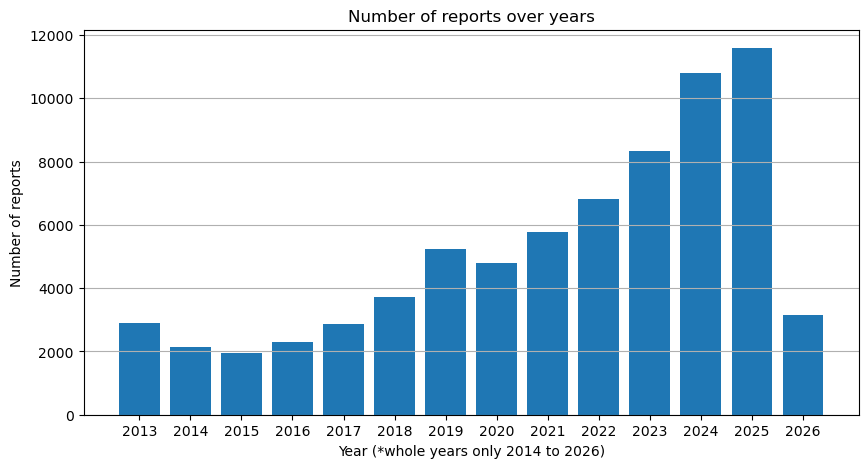

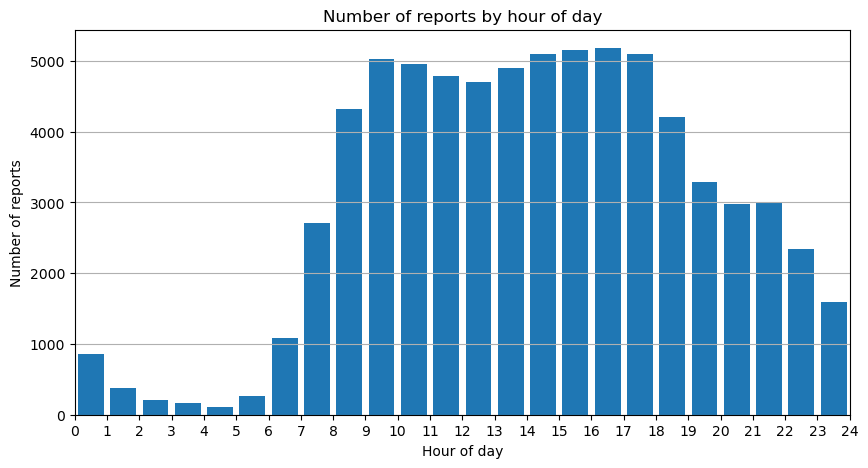

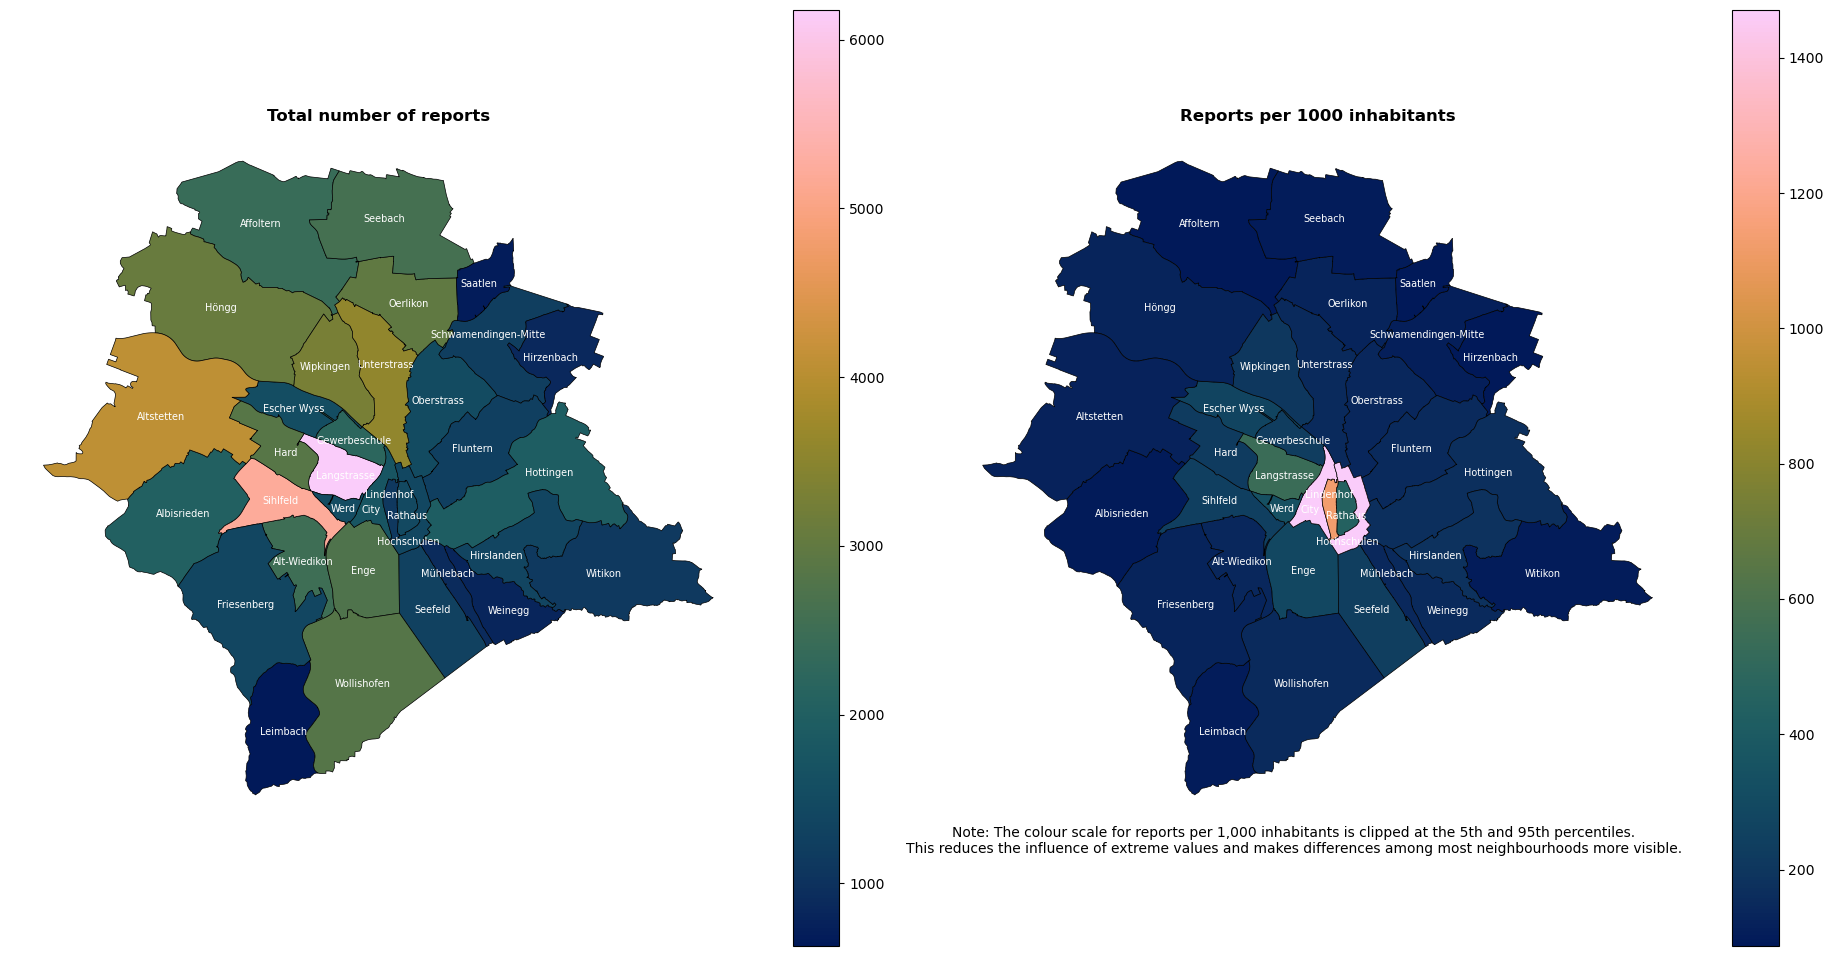

In [8]:
# (2) How does number of reports evolve over the years, diurnal and across neighbourhoods?

# (2.1) Total number of reports per year
# Extract year
reports_gdf["year"] = (
    reports_gdf["requested_datetime"].dt.year
)

# Count the total number of reports per year
report_counts_year = (
    reports_gdf
    .groupby("year")
    .size()
    .reset_index(name="report_count")
)

# Plot the number of reports per year with a bar chart
plt.figure(figsize=(10, 5))

plt.bar(
    report_counts_year["year"],
    report_counts_year["report_count"]
)

plt.title("Number of reports over years")
plt.xlabel("Year (*whole years only 2014 to 2026)")
plt.ylabel("Number of reports")

# Add every year as tick
plt.xticks(report_counts_year["year"])
plt.grid(axis="y")

# save figure to output-folder
save_figure("reports_by_year")

plt.show()

# (2.2) Total number of reports per hour of day
# Extract hour
reports_gdf["hour"] = reports_gdf["requested_datetime"].dt.hour

# Count the total number of reports per hour
report_counts_hour = (
    reports_gdf
    .groupby("hour")
    .size()
    .reset_index(name="report_count")
)

# Plot the number of reports per hour with a bar chart
plt.figure(figsize=(10, 5))

# Shift the bars centered between hour ticks
x_positions = report_counts_hour["hour"] + 0.5

plt.bar(
    x_positions,
    report_counts_hour["report_count"],
    width=0.8
)

plt.title("Number of reports by hour of day")
plt.xlabel("Hour of day")
plt.ylabel("Number of reports")

# Add ticks at hour boundaries
plt.xticks(range(0, 25))
plt.xlim(0, 24)
plt.grid(axis="y")

# save figure to output-folder
save_figure("reports_by_hour")
   
plt.show()

# (2.3) Total reports per neighbourhood normalized by mean population from 2013-2025

# Asses mean population over the reporting period
population_cols = [
    "2013", "2014", "2015", "2016", "2017", "2018", "2019", "2020", "2021", "2022","2023", "2024", "2025"
]

pop_quartiere_gdf["mean_pop_2013-2025"] = (
    pop_quartiere_gdf[population_cols]
    .mean(axis=1)
)
report_counts_quartier = (
    reports_quartier
    .groupby("qname")
    .size()
    .reset_index(name="report_count")
)

# Merge reports per neighbourhood to neighbourhood polygons/population by defining a gdf called quartier_analysis
quartier_analysis = pop_quartiere_gdf.merge(
    report_counts_quartier,
    on="qname",
    how="left"
)

# Calculate reports per 1000 inhabitants
quartier_analysis["reports_per_1000"] = (
    quartier_analysis["report_count"]
    / quartier_analysis["mean_pop_2013-2025"]
) * 1000

# plot total reports and normalized reports as choropleths of neighbourhoods side-by-side
fig, axes = plt.subplots(
    1, 2, 
    figsize=(24, 12),    
    constrained_layout=False    
)

# Decrease unnecessary white space between subplots
plt.subplots_adjust(
    wspace=0.02,
    bottom=0.10
)

# (Left map) total reports
quartier_analysis.plot(
    column="report_count",
    cmap ="cmc.batlow",
    legend=True,
    edgecolor="black",
    linewidth=0.5,
    ax=axes[0]
)

axes[0].set_title("Total number of reports", fontsize=12, fontweight="bold")
axes[0].axis("off")

# (Right map) reports per 1000 inhabitants
# Calculate the 5% and 95% quantiles to scale the display.
vmin = quartier_analysis["reports_per_1000"].quantile(0.05)
vmax = quartier_analysis["reports_per_1000"].quantile(0.95)
quartier_analysis.plot(
    column="reports_per_1000",
    cmap ="cmc.batlow",
    legend=True,
    vmin=vmin,
    vmax=vmax,
    edgecolor="black",
    linewidth=0.5,
    ax=axes[1]
)

axes[1].set_title("Reports per 1000 inhabitants", fontsize=12, fontweight="bold")
axes[1].axis("off")

# Add note below the figure
fig.text(
    0.66, 0.2,
    "Note: The colour scale for reports per 1,000 inhabitants is clipped at the 5th and 95th percentiles.\n"
    "This reduces the influence of extreme values and makes differences among most neighbourhoods more visible.",
    ha="center",
    va="top",
    fontsize=10
)

for ax in axes:
    add_quartier_labels(ax)
save_figure("choropleth_reports_combined")
    
plt.show()

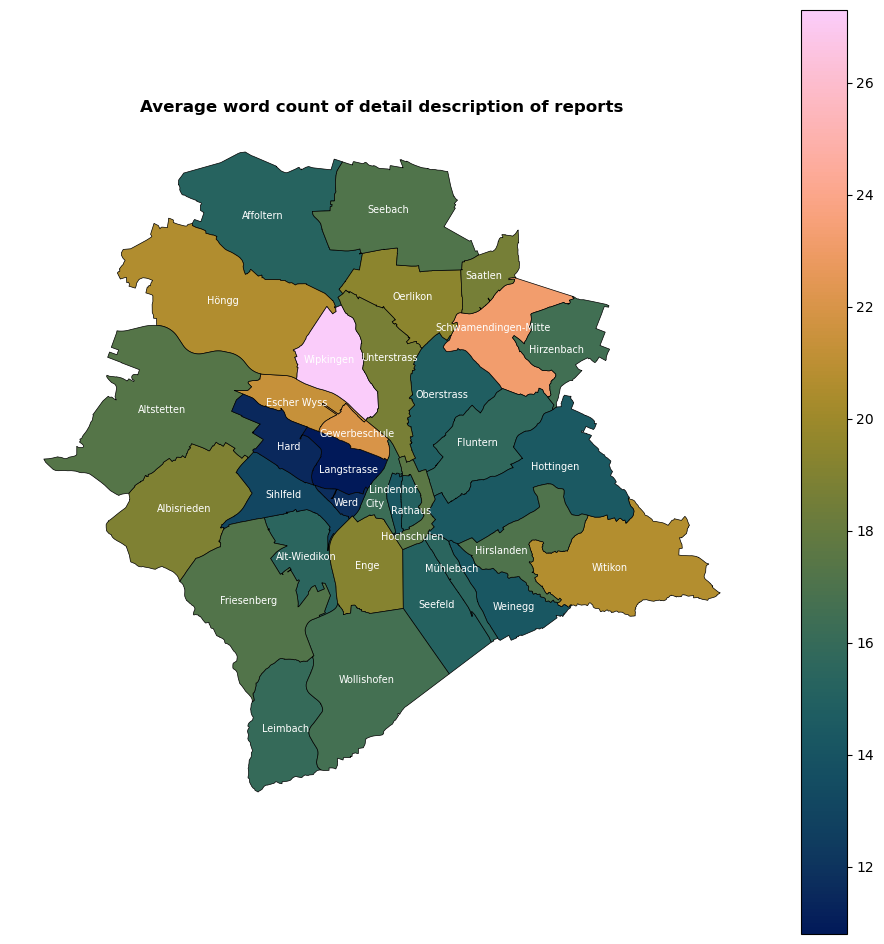

In [3]:
# (3) Which neighbourhoods make the most detailed reports (average number of words)?

# Count words in each report detail
reports_quartier["word_count"] = (
    reports_quartier["detail"]
    .str.split() # splits detail in a list of single words
    .str.len() # counts length of the list
)

# Average words per neighbourhood
avg_word_count = (
    reports_quartier
    .groupby("qname")["word_count"]
    .mean()
    .reset_index(name="avg_word_count")
    .sort_values("avg_word_count", ascending=False)
)

# Merge to quartier_analysis to map on the neighbourhod polygons
quartier_analysis = quartier_analysis.merge(
    avg_word_count,
    on="qname",
    how="left"
)

# plot report length as choropleths of neighbourhoods
fig, ax = plt.subplots(figsize=(12, 12))


quartier_analysis.plot(
    column="avg_word_count",
    cmap ="cmc.batlow",
    legend=True,
    edgecolor="black",
    linewidth=0.5,
    ax=ax
)

ax.set_title("Average word count of detail description of reports", 
    fontsize=12, 
    fontweight="bold"
)
ax.axis("off")

add_quartier_labels(ax)
save_figure("choropleth_word_count.png")

plt.show()

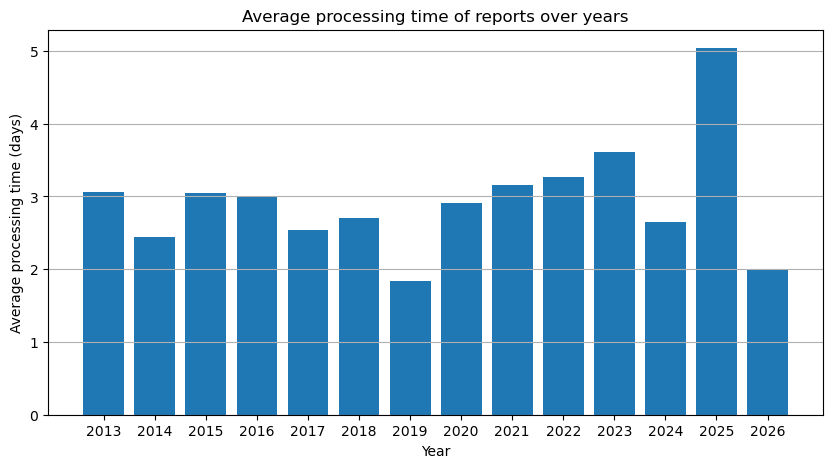

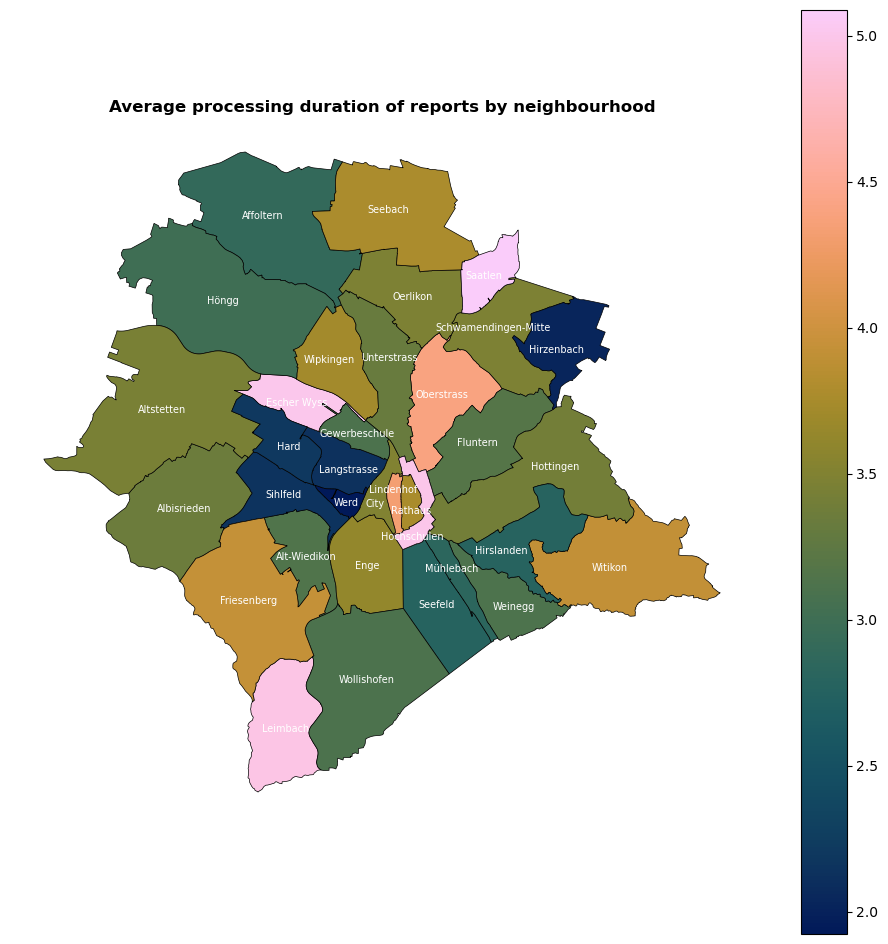

In [4]:
# (4) How does the processing of the reports by the council vary over years and neighbourhoods?

# (4.1) Average processing duration by year
# Only reports that were fixed by the municipal offices ("status"="fixed - council")
fixed_reports = reports_quartier[
    reports_quartier["status"] == "fixed - council"
].copy()

# Calculate processing duration for these reports in decimal days
fixed_reports["processing_time"] = (
    fixed_reports["updated_datetime"]
    - fixed_reports["requested_datetime"]
)

fixed_reports["processing_days"] = (
    fixed_reports["processing_time"]
    .dt.total_seconds() / (60 * 60 * 24)
)

# Calculate average processing duration per year
fixed_reports["year"] = (
    fixed_reports["requested_datetime"].dt.year
)

processing_time_year = (
    fixed_reports
    .groupby("year")["processing_days"]
    .mean()
    .reset_index(name="avg_processing_days")
    .sort_values("year", ascending=True)
)

# Plot the the evolution of average processing time with a bar chart
plt.figure(figsize=(10, 5))

plt.bar(
    processing_time_year["year"],
    processing_time_year["avg_processing_days"]
)

plt.title("Average processing time of reports over years")
plt.xlabel("Year")
plt.ylabel("Average processing time (days)")

# every year as tick
plt.xticks(processing_time_year["year"])
plt.grid(axis="y")

# save figure to output-folder
save_figure("processing_by_year")

plt.show()

# (4.2) Average processing duration by neighbourhood
processing_time_by_quartier = (
    fixed_reports
    .groupby("qname")["processing_days"]
    .mean()
    .reset_index(name="avg_processing_days")
    .sort_values("avg_processing_days", ascending=True)
)

# Merge to quartier_analysis to map on the neighbourhod polygons
quartier_analysis = quartier_analysis.merge(
    processing_time_by_quartier,
    on="qname",
    how="left"
)

# plot report length as choropleths of neighbourhoods
fig, ax = plt.subplots(figsize=(12, 12))

quartier_analysis.plot(
    column="avg_processing_days",
    cmap ="cmc.batlow",
    legend=True,
    edgecolor="black",
    linewidth=0.5,
    ax=ax
)

ax.set_title(
    "Average processing duration of reports by neighbourhood", 
    fontsize=12, 
    fontweight="bold"
)
ax.axis("off")

add_quartier_labels(ax)
save_figure("choropleth_processing_days")

plt.show()

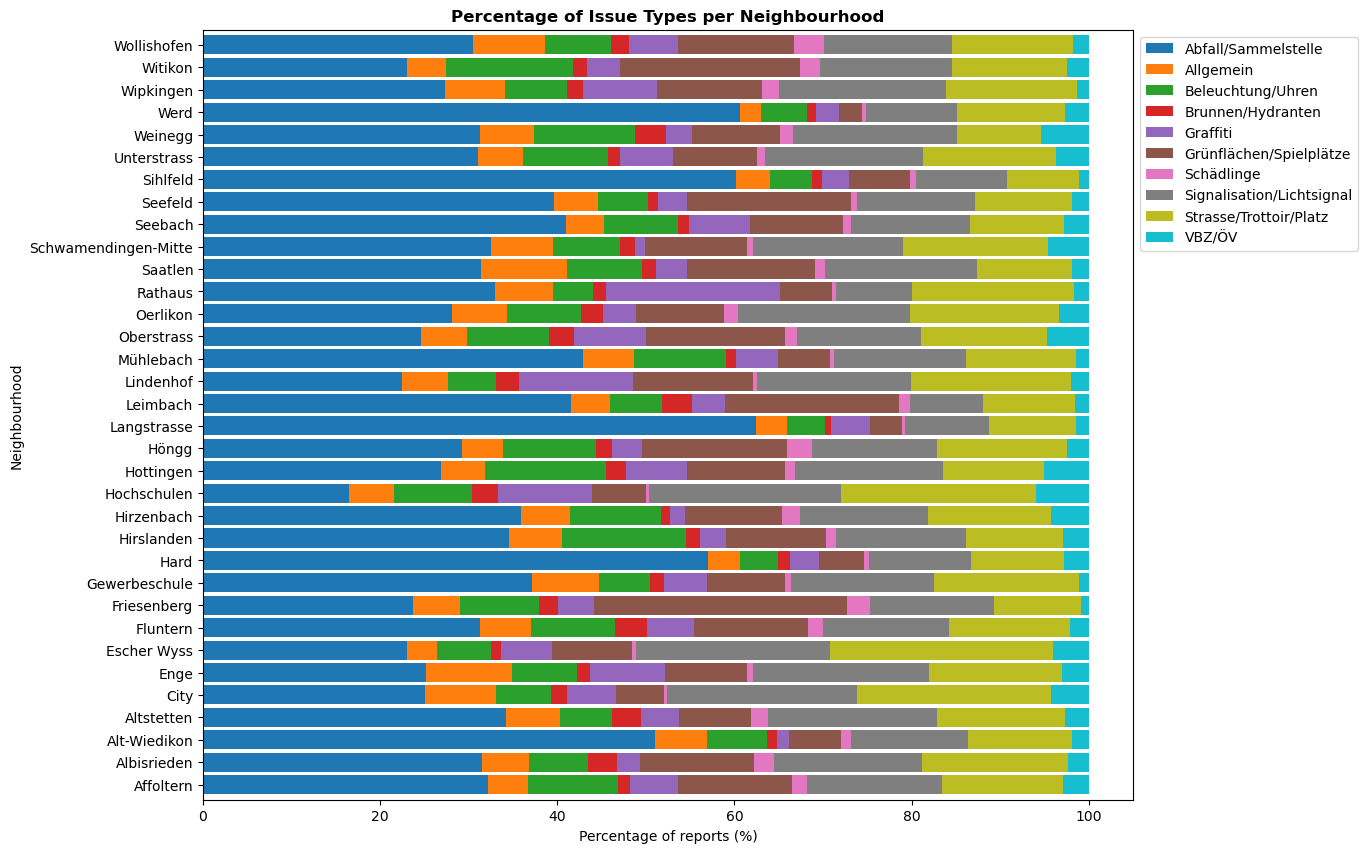

In [5]:
# (5) What percentage of reports in a neighbourhood belong to each issue type?

# Calculate percentage share of each issue type per neighbourhood
# Pandas crosstable counts how often a combination from a qname and service_name appers. Then this is normalized and multiplied to percentages
issue_shares = pd.crosstab(
    reports_quartier["qname"],
    reports_quartier["service_name"],
    normalize="index"
) * 100

# Plot stacked horizontal bar chart
ax = issue_shares.plot(
    kind="barh",
    stacked=True,
    figsize=(12, 10),
    width=0.85
)

ax.set_xlabel("Percentage of reports (%)")
ax.set_ylabel("Neighbourhood")
ax.set_title(
    "Percentage of Issue Types per Neighbourhood",
    fontsize=12,
    fontweight="bold"
)

ax.legend(
    bbox_to_anchor= (1, 1),
    loc="upper left"
)

save_figure("service_type_shares")

plt.show()

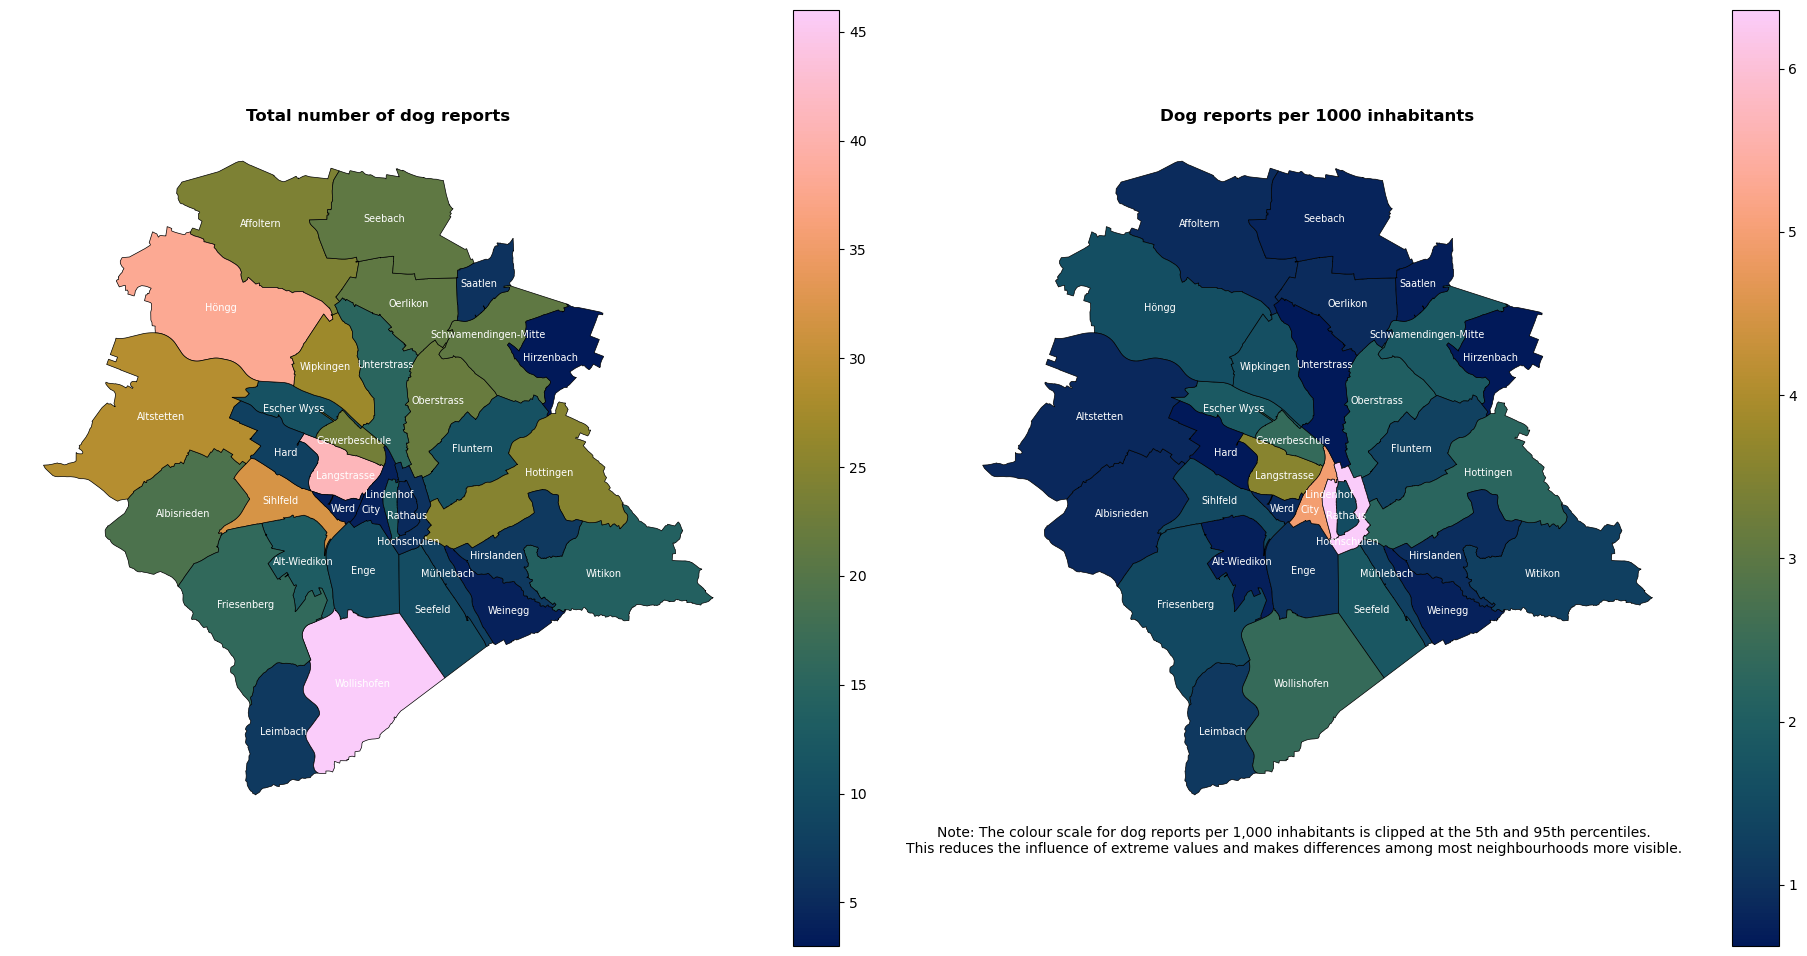

In [6]:
# (6) How frequent are dog-related problems reported per neighbourhood?

# Normalize text of "detail"-column to make keyword search work
reports_quartier["detail"] = (
    reports_quartier["detail"]
    .fillna("") # replaces potential NaN with empty strings
    .astype(str) # ensures that all detail descriptions are text
    .str.lower() # converts all text to lowercase
)

# Search word stem "hund" but exclude "hundert(e)" (regex syntax)
hund_reports = reports_quartier[
    reports_quartier["detail"].str.contains(
        r"\b\w*hund(?!ert)\w*\b",
        regex=True
    )
].copy()

# Count number of dog problems per neighbourhood
hund_by_quartier = (
    hund_reports
    .groupby("qname")
    .size()
    .reset_index(name="hund_reports_count")
)

# Merge to quartier_analysis to map on the neighbourhod polygons
quartier_analysis = quartier_analysis.merge(
    hund_by_quartier,
    on="qname",
    how="left"
)

# Calculate dog-related reports per 1,000 inhabitants
quartier_analysis["hund_reports_per_1000"] = (
    quartier_analysis["hund_reports_count"]
    / quartier_analysis["mean_pop_2013-2025"]
) * 1000

# plot total dog reports and normalized dog reports as choropleths of neighbourhoods side-by-side
fig, axes = plt.subplots(
    1, 2, 
    figsize=(24, 12),
    constrained_layout=False    
)

# Decrease unnecessary white space between subplots
plt.subplots_adjust(
    wspace=0.02,
    bottom=0.10
)

# (Left map) total reports
quartier_analysis.plot(
    column="hund_reports_count",
    cmap ="cmc.batlow",
    legend=True,
    edgecolor="black",
    linewidth=0.5,
    ax=axes[0]
)

axes[0].set_title("Total number of dog reports", fontsize=12, fontweight="bold")
axes[0].axis("off")

# (Right map) reports per 1000 inhabitants
# Calculate the 5% and 95% quantiles to scale the display.
vmin = quartier_analysis["hund_reports_per_1000"].quantile(0.05)
vmax = quartier_analysis["hund_reports_per_1000"].quantile(0.95)

quartier_analysis.plot(
    column="hund_reports_per_1000",
    cmap ="cmc.batlow",
    vmin=vmin,
    vmax=vmax,
    legend=True,
    edgecolor="black",
    linewidth=0.5,
    ax=axes[1]
)

axes[1].set_title("Dog reports per 1000 inhabitants", fontsize=12, fontweight="bold")
axes[1].axis("off")

# Add note below the figure
fig.text(
    0.66, 0.2,
    "Note: The colour scale for dog reports per 1,000 inhabitants is clipped at the 5th and 95th percentiles.\n"
    "This reduces the influence of extreme values and makes differences among most neighbourhoods more visible.",
    ha="center",
    va="top",
    fontsize=10
)

for ax in axes:
    add_quartier_labels(ax)
save_figure("choropleth_reports_combined")

plt.show()